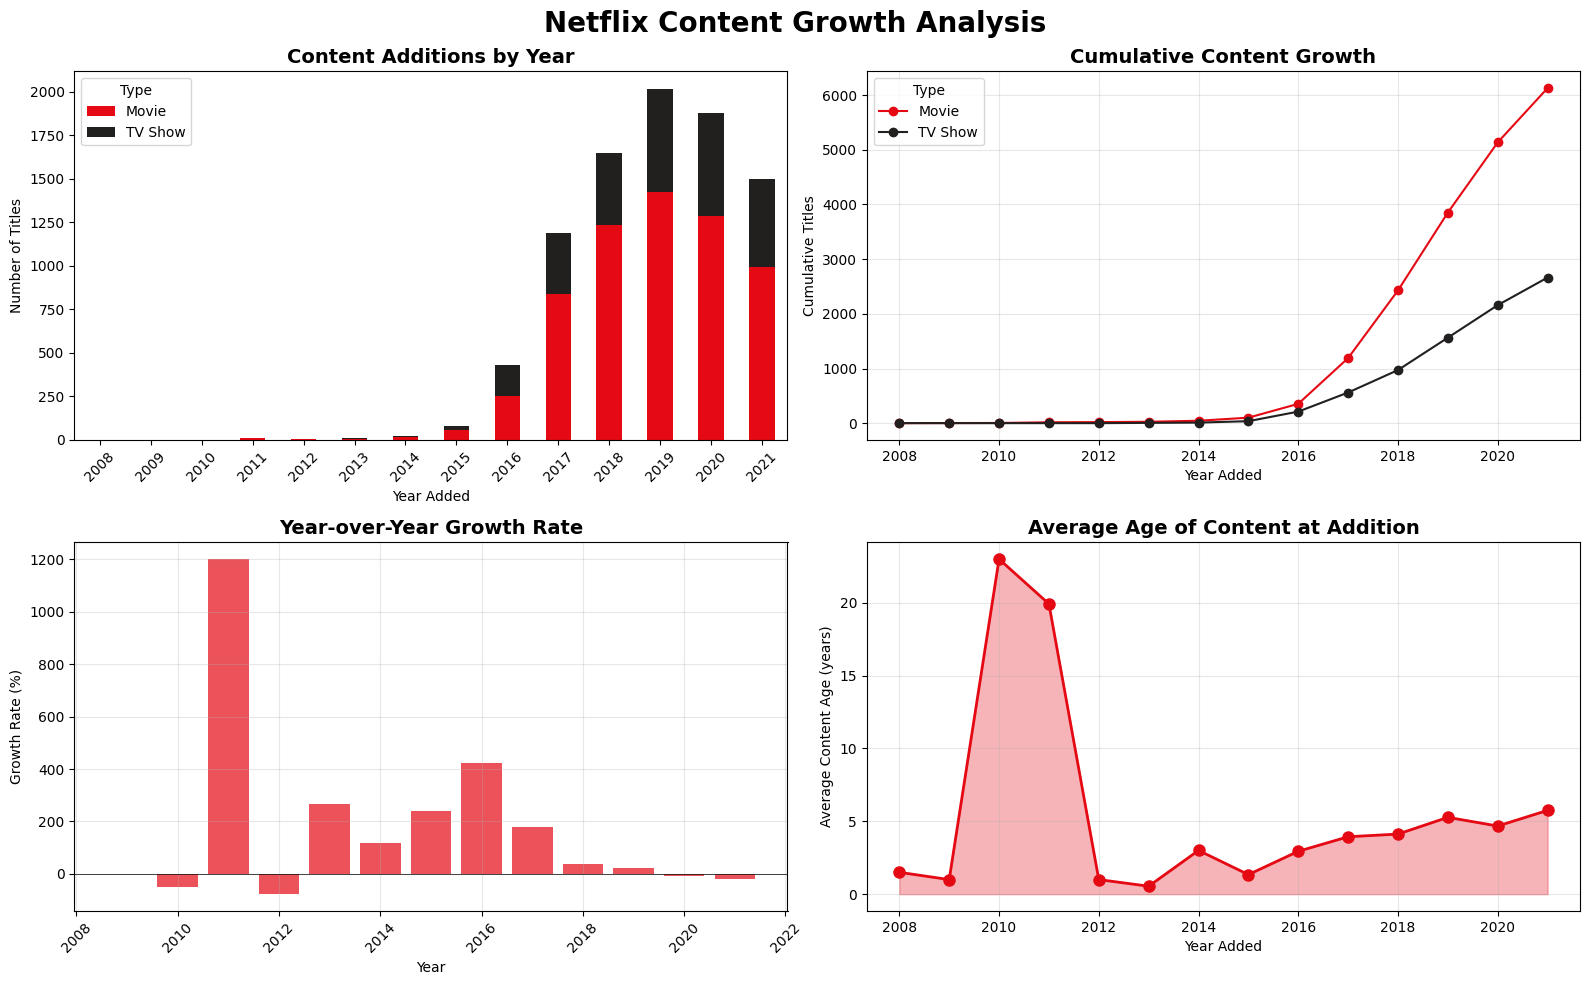


🔍 KEY INSIGHTS FROM TEMPORAL ANALYSIS:
--------------------------------------------------
📊 Content added pre-2016: 138
📊 Content added 2016 onwards: 8655
📈 Growth rate: 6171.7%
⏱️  Avg content age (pre-2016): 3.5 years
⏱️  Avg content age (post-2016): 4.7 years


In [3]:
# 03_temporal_analysis.ipynb

# Cell 4: Temporal Analysis - Content Growth Over Time
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

# Load your data if not already loaded
df = pd.read_csv('D:/Netflix content strategy analysis/data/processed data/netflix_clean_data.csv')

# Create a figure for temporal analysis
fig = plt.figure(figsize=(16, 10))
fig.suptitle('Netflix Content Growth Analysis', fontsize=20, fontweight='bold')

# 1. Yearly additions (Movies vs TV Shows)
ax1 = plt.subplot(2, 2, 1)

# Group by year and type
yearly_trends = df.groupby(['year_added', 'type']).size().unstack().fillna(0)

# Plot stacked bar chart
yearly_trends.plot(kind='bar', stacked=True, color=['#E50914', '#221f1f'], ax=ax1)
ax1.set_xlabel('Year Added')
ax1.set_ylabel('Number of Titles')
ax1.set_title('Content Additions by Year', fontsize=14, fontweight='bold')
ax1.legend(title='Type')
ax1.tick_params(axis='x', rotation=45)

# 2. Cumulative growth
ax2 = plt.subplot(2, 2, 2)
cumulative = yearly_trends.cumsum()
cumulative.plot(kind='line', marker='o', color=['#E50914', '#221f1f'], ax=ax2)
ax2.set_xlabel('Year Added')
ax2.set_ylabel('Cumulative Titles')
ax2.set_title('Cumulative Content Growth', fontsize=14, fontweight='bold')
ax2.grid(True, alpha=0.3)
ax2.legend(title='Type')

# 3. Growth rate
ax3 = plt.subplot(2, 2, 3)
total_yearly = yearly_trends.sum(axis=1)
growth_rate = total_yearly.pct_change() * 100
ax3.bar(growth_rate.index, growth_rate.values, color='#E50914', alpha=0.7)
ax3.axhline(y=0, color='black', linestyle='-', linewidth=0.5)
ax3.set_xlabel('Year')
ax3.set_ylabel('Growth Rate (%)')
ax3.set_title('Year-over-Year Growth Rate', fontsize=14, fontweight='bold')
ax3.tick_params(axis='x', rotation=45)
ax3.grid(True, alpha=0.3)

# 4. Content age at addition
ax4 = plt.subplot(2, 2, 4)
if 'content_age_at_addition' in df.columns:
    age_by_year = df.groupby('year_added')['content_age_at_addition'].mean()
    ax4.plot(age_by_year.index, age_by_year.values, marker='o', 
             color='#E50914', linewidth=2, markersize=8)
    ax4.fill_between(age_by_year.index, age_by_year.values, alpha=0.3, color='#E50914')
    ax4.set_xlabel('Year Added')
    ax4.set_ylabel('Average Content Age (years)')
    ax4.set_title('Average Age of Content at Addition', fontsize=14, fontweight='bold')
    ax4.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('D:/Netflix content strategy analysis/outputs/figures/temporal_analysis.png', dpi=300, bbox_inches='tight')
plt.show()

# Print key insights
print("\n🔍 KEY INSIGHTS FROM TEMPORAL ANALYSIS:")
print("-" * 50)
pre_2016 = df[df['year_added'] < 2016].shape[0]
post_2016 = df[df['year_added'] >= 2016].shape[0]
growth_pct = ((post_2016 - pre_2016) / pre_2016) * 100
print(f"📊 Content added pre-2016: {pre_2016}")
print(f"📊 Content added 2016 onwards: {post_2016}")
print(f"📈 Growth rate: {growth_pct:.1f}%")

if 'content_age_at_addition' in df.columns:
    avg_age_pre = df[df['year_added'] < 2016]['content_age_at_addition'].mean()
    avg_age_post = df[df['year_added'] >= 2016]['content_age_at_addition'].mean()
    print(f"⏱️  Avg content age (pre-2016): {avg_age_pre:.1f} years")
    print(f"⏱️  Avg content age (post-2016): {avg_age_post:.1f} years")